In [24]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torchvision import models
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import random
from collections import defaultdict
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from PIL import Image
import torch
import torch.nn as nn
from torchvision import models
import torch.optim as optim
import torch.nn as nn
import time
import copy# --- Step 7: Evaluate the Model on Validation Set ---
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import os



In [3]:
from pathlib import Path

dataset_path = Path("Brain_Stroke_CT_Dataset")

if not dataset_path.exists():
    print(f"Error: Path {dataset_path} does not exist")
else:
    print(f"Dataset path: {dataset_path}")
    
    print("\nDirectory structure:")
    for item in dataset_path.iterdir():
        if item.is_dir():
            print(f"\n📁 {item.name}")
            file_count = len(list(item.glob('*')))
            print(f"   Contains {file_count} files")
            
            print("   Example files:")
            for file_path in list(item.glob('*'))[:3]:
                print(f"   - {file_path.name}")
            
            if file_count > 3:
                print(f"   - ... and {file_count - 3} more files")
        else:
            print(f"📄 {item.name}")
    
    total_images = len(list(dataset_path.glob('**/*.png'))) + len(list(dataset_path.glob('**/*.jpg')))
    print(f"\nTotal images found: {total_images}")


KaggleApiHTTPError: 404 Client Error.

Resource not found at URL: https://www.kaggle.com/datasets/ozguraslank/brain-stroke-ct-dataset/versions/3
The server reported the following issues: Dataset not found
Please make sure you specified the correct resource identifiers.

In [3]:


def set_seed(seed=42):
    """
    Set seeds for reproducibility across different libraries
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)  # if using multi-GPU
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False
    # Using environment variables with pathlib
    Path.home().joinpath('.bashrc')  # This is just to demonstrate pathlib usage
    # We still need to set PYTHONHASHSEED environment variable
    import os  # Still need os for environment variable
    os.environ['PYTHONHASHSEED'] = str(seed)
    print(f"Seeds set to {seed} for reproducibility")

# Set the seed
set_seed(42)


Seeds set to 42 for reproducibility


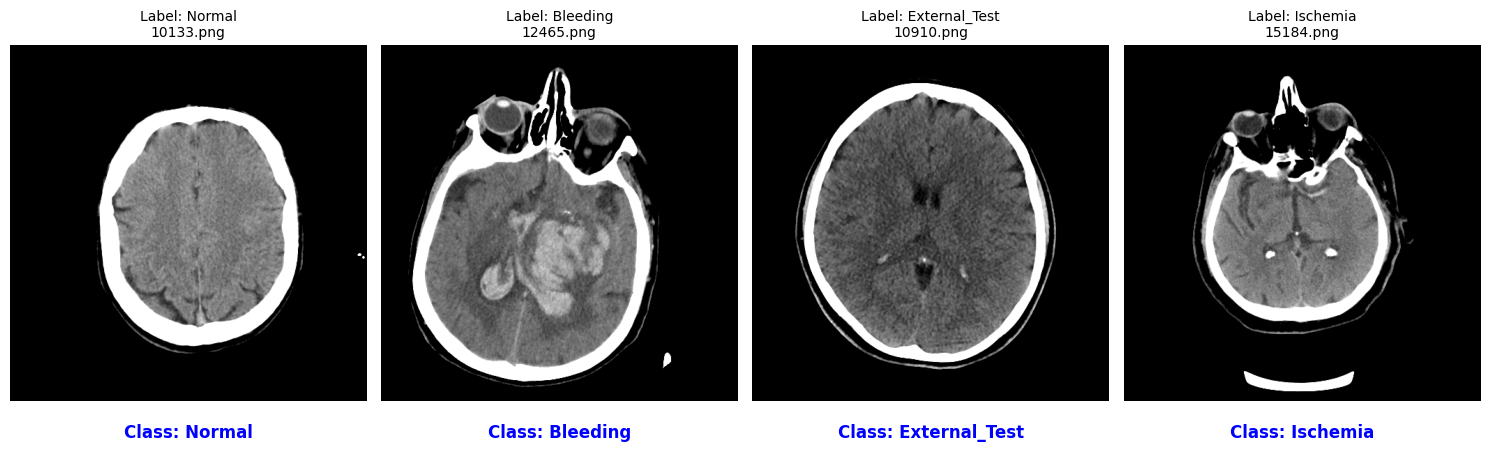

Displayed 4 images from 4 categories:
- 10133.png (Label: Normal)
- 12465.png (Label: Bleeding)
- 10910.png (Label: External_Test)
- 15184.png (Label: Ischemia)


In [8]:

def show_sample_images(dataset_path, num_samples_per_category=1):
    # Group images by category
    categories = defaultdict(list)
    for img_path in list(dataset_path.glob('**/PNG/*.png')) + list(dataset_path.glob('**/PNG/*.jpg')):
        # Extract label from parent folder name
        label = img_path.parent.parent.name
        categories[label].append(img_path)
    
    if not categories:
        print("No image files found in PNG folders within the dataset.")
        return
    
    # Select samples from each category
    samples = []
    for label, images in categories.items():
        samples.extend(random.sample(images, min(num_samples_per_category, len(images))))
    
    fig, axes = plt.subplots(1, len(samples), figsize=(15, 5))
    
    if len(samples) == 1:
        axes = [axes]
    
    for i, img_path in enumerate(samples):
        img = plt.imread(img_path)
        axes[i].imshow(img)
        
        # Extract label from parent folder name
        label = img_path.parent.parent.name
        
        # Display both the label and filename in the title
        axes[i].set_title(f"Label: {label}\n{img_path.name}", fontsize=10)
        
        # Add a colored background to emphasize the label
        axes[i].set_facecolor('lightgray')
        
        # Add label text at the bottom of the image
        axes[i].text(0.5, -0.1, f"Class: {label}", 
                    horizontalalignment='center',
                    transform=axes[i].transAxes,
                    fontsize=12, 
                    fontweight='bold',
                    color='blue')
        
        axes[i].axis('off')
    
    plt.tight_layout()
    plt.show()
    
    # Print summary of displayed images with their labels
    print(f"Displayed {len(samples)} images from {len(categories)} categories:")
    for img_path in samples:
        print(f"- {img_path.name} (Label: {img_path.parent.parent.name})")

# Show one sample from each category
show_sample_images(dataset_path)


In [15]:
image_paths = []
labels = []

print("Scanning dataset directory...")
# 1. Gather paths and labels
for class_dir in dataset_path.iterdir():
    if class_dir.is_dir():
        label = class_dir.name # e.g., 'Stroke', 'Non_Stroke'
        print(f"Found class: {label}")
        # Ignore External_Test folder
        if "External_Test" in str(class_dir):
            print(f"  Skipping External_Test folder")
            continue
        # Look for images directly within the class folder or common subfolders like 'PNG'
        # Adjust glob pattern if your structure is different
        found_images = list(class_dir.glob('**//PNG/*.png')) + list(class_dir.glob('**//PNG/*.jpg'))
        print(f"  Found {len(found_images)} images.")
        for img_path in found_images:
             # Store the absolute path as a string for compatibility
             image_paths.append(str(img_path.resolve()))
             labels.append(label)

if not image_paths:
    print("\nError: No images found. Please check the dataset_path and directory structure.")
else:
    print(f"\nTotal images collected: {len(image_paths)}")

    # 2. Create a Pandas DataFrame
    df = pd.DataFrame({
        'path': image_paths,
        'label': labels
    })

    # 3. Map labels to integers
    unique_labels = df['label'].unique().tolist()
    label_map = {label: i for i, label in enumerate(unique_labels)}
    print(f"Label map created: {label_map}")

    df['label_encoded'] = df['label'].map(label_map)

    print("\nOriginal DataFrame sample:")
    print(df.head())

    # 4. Split the data into Training (e.g., 85%) and Validation (e.g., 15%)
    # We will handle the test set separately later.
    train_df, val_df = train_test_split(
        df,
        test_size=0.15, # Use test_size to define the validation set size (e.g., 15%)
        random_state=42,
        stratify=df['label_encoded'] # Stratify based on encoded labels
    )

    print("\n--- Split Results ---")
    print(f"Train set size: {len(train_df)}")
    print(f"Validation set size: {len(val_df)}")

    print("\nTrain set label distribution:")
    print(train_df['label'].value_counts())
    print("\nValidation set label distribution:")
    print(val_df['label'].value_counts())

    # Keep the resulting DataFrames for the next steps
    # (train_df, val_df)

Scanning dataset directory...
Found class: Normal
  Found 4427 images.
Found class: Bleeding
  Found 1093 images.
Found class: External_Test
  Skipping External_Test folder
Found class: Ischemia
  Found 1130 images.

Total images collected: 6650
Label map created: {'Normal': 0, 'Bleeding': 1, 'Ischemia': 2}

Original DataFrame sample:
                                                path   label  label_encoded
0  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Normal              0
1  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Normal              0
2  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Normal              0
3  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Normal              0
4  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Normal              0

--- Split Results ---
Train set size: 5652
Validation set size: 998

Train set label distribution:
label
Normal      3763
Ischemia     960
Bleeding     929
Name: count, dtype: int64

Validation set label di

In [16]:
# --- Step 1: Define Image Transformations ---
from torchvision import transforms

# Define image size and normalization stats (common for ImageNet pre-trained models)
IMG_SIZE = 224
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# Transformations for the training set (with augmentation)
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Resize images
    transforms.RandomHorizontalFlip(),      # Randomly flip images horizontally
    transforms.RandomRotation(10),          # Randomly rotate images by up to 10 degrees
    transforms.ToTensor(),                  # Convert image to PyTorch Tensor (scales pixels to [0, 1])
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # Normalize with ImageNet stats
])

# Transformations for the validation/test set (no augmentation)
val_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)), # Resize images
    transforms.ToTensor(),                  # Convert image to PyTorch Tensor
    transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD) # Normalize with ImageNet stats
])

print("Image transformations defined:")
print("Training Transforms:\n", train_transforms)
print("\nValidation Transforms:\n", val_transforms)

Image transformations defined:
Training Transforms:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    RandomHorizontalFlip(p=0.5)
    RandomRotation(degrees=[-10.0, 10.0], interpolation=nearest, expand=False, fill=0)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)

Validation Transforms:
 Compose(
    Resize(size=(224, 224), interpolation=bilinear, max_size=None, antialias=True)
    ToTensor()
    Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
)


In [19]:

class BrainCTDataset(Dataset):
    """Custom Dataset for loading Brain CT images using pandas."""

    def __init__(self, dataframe: pd.DataFrame, transform=None): # Changed type hint to pd.DataFrame
        """
        Args:
            dataframe (pandas.DataFrame): DataFrame containing image paths and labels.
                                          Expected columns: 'path', 'label_encoded'.
            transform (callable, optional): Optional transform to be applied
                                            on a sample.
        """
        self.df = dataframe
        self.transform = transform
        # Extract paths and labels using pandas accessors
        self.image_paths = self.df['path'].tolist() # Use pandas .tolist()
        self.labels = self.df['label_encoded'].tolist() # Use pandas .tolist()

    def __len__(self):
        """Returns the total number of samples in the dataset."""
        return len(self.df)

    def __getitem__(self, idx):
        """
        Fetches the sample (image and label) at the given index.

        Args:
            idx (int): The index of the sample to retrieve.

        Returns:
            tuple: (image, label) where image is the transformed image tensor,
                   and label is the integer label.
        """
        # Get image path and label for the given index
        # Using .iloc is robust for integer indexing in pandas
        img_path = self.image_paths[idx] # Accessing list directly is fine here
        label = self.labels[idx]         # Accessing list directly is fine here

        # Load the image
        try:
            # Open the image using PIL
            image = Image.open(img_path).convert('RGB') # Convert to RGB
        except FileNotFoundError:
            print(f"Error: Image file not found at {img_path}")
            raise FileNotFoundError(f"Image file not found at {img_path}")
        except Exception as e:
            print(f"Error loading image {img_path}: {e}")
            raise e # Re-raise the exception

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Return the transformed image and its label
        return image, torch.tensor(label, dtype=torch.long)




print("BrainCTDataset class defined (using pandas).")


BrainCTDataset class defined (using pandas).


In [20]:
train_dataset = BrainCTDataset(dataframe=train_df, transform=train_transforms)
val_dataset = BrainCTDataset(dataframe=val_df, transform=val_transforms)

print(f"Training dataset size: {len(train_dataset)}")
print(f"Validation dataset size: {len(val_dataset)}")

# 2. Define DataLoader parameters
BATCH_SIZE = 32 # Adjust based on your GPU memory
NUM_WORKERS = 2 # Adjust based on your CPU cores (0 means main process loads data)

# 3. Create the DataLoaders
train_loader = DataLoader(
    dataset=train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,  # Shuffle training data each epoch
    num_workers=NUM_WORKERS,
    pin_memory=True # Helps speed up data transfer to GPU if using CUDA
)

val_loader = DataLoader(
    dataset=val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False, # No need to shuffle validation data
    num_workers=NUM_WORKERS,
    pin_memory=True
)

print(f"\nDataLoaders created with Batch Size: {BATCH_SIZE}")


Training dataset size: 5652
Validation dataset size: 998

DataLoaders created with Batch Size: 32


In [ ]:
NUM_CLASSES = len(train_df['label'].unique())
print(f"Detected {NUM_CLASSES} unique classes in the dataset")

# 2. Load the pre-trained ResNet-18 model
# weights='IMAGENET1K_V1' is the modern way to specify pre-trained weights
model = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

# 3. Modify the final fully connected layer (classifier)
# ResNet's final layer is usually named 'fc'
num_ftrs = model.fc.in_features # Get the number of input features to the original fc layer
model.fc = nn.Linear(num_ftrs, NUM_CLASSES) # Replace it with a new linear layer for our classes

# Print the model layers to see the architecture
print("ResNet-18 Model Architecture:")
for name, module in model.named_children():
    print(f"{name}: {module}")



# 4. Set the device (GPU if available, otherwise CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = model.to(device) # Move the model to the selected device

print(f"Using device: {device}")
print(f"Model architecture loaded: ResNet-18")
print(f"Final layer modified for {NUM_CLASSES} classes.")


Detected 3 unique classes in the dataset
ResNet-18 Model Architecture:
conv1: Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
bn1: BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
relu: ReLU(inplace=True)
maxpool: MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
layer1: Sequential(
  (0): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): ReLU(inplace=True)
    (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  )
  (1): BasicBlock(
    (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (relu): 

In [27]:
criterion = nn.CrossEntropyLoss()

LEARNING_RATE = 0.001 # Common starting point for Adam
optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

# You could also try other optimizers like SGD or AdamW:
# optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
# optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

print(f"Loss function: {criterion}")
print(f"Optimizer: {optimizer}")
print(f"Learning Rate: {LEARNING_RATE}")


Loss function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)
Learning Rate: 0.001


In [28]:
NUM_EPOCHS = 30 # Increased to 30 epochs
PATIENCE = 5 # Number of epochs to wait for improvement before stopping

# Ensure necessary variables (model, train_loader, criterion, optimizer, device) are defined
if 'model' not in locals() or 'train_loader' not in locals() or 'val_loader' not in locals() or \
   'criterion' not in locals() or 'optimizer' not in locals() or 'device' not in locals():
    print("Error: Ensure model, train_loader, val_loader, criterion, optimizer, and device are defined before training.")
    # Depending on the environment, you might raise an error or exit
    raise NameError("Required training components not defined.")

print(f"Starting training for up to {NUM_EPOCHS} epochs on {device} with early stopping (patience={PATIENCE})...")

# Store training loss history
train_loss_history = []
val_loss_history = []

# Variables for early stopping
best_val_loss = float('inf')
best_model_wts = copy.deepcopy(model.state_dict())
counter = 0  # Counter for patience

for epoch in range(NUM_EPOCHS):
    start_time = time.time()
    
    # Training phase
    model.train()  # Set the model to training mode (enables dropout, batch norm updates)
    running_loss = 0.0
    running_corrects = 0
    total_samples = 0

    # Iterate over batches from the training loader
    for i, (inputs, labels) in enumerate(train_loader):
        # Move inputs and labels to the correct device (GPU or CPU)
        inputs = inputs.to(device)
        labels = labels.to(device)

        # 1. Zero the parameter gradients
        optimizer.zero_grad()

        # 2. Forward pass: compute predicted outputs by passing inputs to the model
        outputs = model(inputs)

        # 3. Calculate the loss
        loss = criterion(outputs, labels)

        # 4. Backward pass: compute gradient of the loss with respect to model parameters
        loss.backward()

        # 5. Perform a single optimization step (parameter update)
        optimizer.step()

        # --- Statistics ---
        # Add the batch loss to the running loss
        # item() gets the scalar value from the loss tensor
        _, preds = torch.max(outputs, 1)
        running_loss += loss.item() * inputs.size(0)
        running_corrects += torch.sum(preds == labels.data)
        total_samples += inputs.size(0)

        # Print progress every N batches (e.g., every 10 batches)
        if (i + 1) % 10 == 0:
            print(f' Epoch {epoch+1}/{NUM_EPOCHS} | Batch {i+1}/{len(train_loader)} | Loss: {loss.item():.4f}')

    # Calculate average loss for the epoch
    epoch_loss = running_loss / total_samples
    epoch_acc = running_corrects.double() / total_samples * 100 # Calculate epoch accuracy here
    train_loss_history.append(epoch_loss)
    
    # Validation phase
    model.eval()  # Set model to evaluation mode
    val_running_loss = 0.0
    val_running_corrects = 0
    val_total_samples = 0
    
    with torch.no_grad():  # Disable gradient calculation for validation
        for inputs, labels in val_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            
            _, preds = torch.max(outputs, 1)
            val_running_loss += loss.item() * inputs.size(0)
            val_running_corrects += torch.sum(preds == labels.data)
            val_total_samples += inputs.size(0)
    
    val_epoch_loss = val_running_loss / val_total_samples
    val_epoch_acc = val_running_corrects.double() / val_total_samples * 100
    val_loss_history.append(val_epoch_loss)
    
    end_time = time.time()
    epoch_duration = end_time - start_time

    print(f'--- Epoch {epoch+1}/{NUM_EPOCHS} Finished ---')
    print(f' Training Loss: {epoch_loss:.4f} Acc: {epoch_acc:.2f}%')
    print(f' Validation Loss: {val_epoch_loss:.4f} Acc: {val_epoch_acc:.2f}%')
    print(f' Duration: {epoch_duration:.2f} seconds')
    print('-' * 30)
    
    # Early stopping check
    if val_epoch_loss < best_val_loss:
        print(f"Validation loss decreased ({best_val_loss:.4f} --> {val_epoch_loss:.4f}). Saving model...")
        best_val_loss = val_epoch_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        counter = 0  # Reset counter
    else:
        counter += 1
        print(f"Early stopping counter: {counter}/{PATIENCE}")
        if counter >= PATIENCE:
            print(f"Early stopping triggered after {epoch+1} epochs")
            break

# Load the best model weights
model.load_state_dict(best_model_wts)
print('Finished Training')
print(f"Best validation loss: {best_val_loss:.4f}")
# The train_loss_history and val_loss_history lists now contain the average loss for each epoch
print("Training loss history:", train_loss_history)
print("Validation loss history:", val_loss_history)

Starting training for up to 30 epochs on cuda with early stopping (patience=5)...
 Epoch 1/30 | Batch 10/177 | Loss: 0.5445
 Epoch 1/30 | Batch 20/177 | Loss: 0.4834
 Epoch 1/30 | Batch 30/177 | Loss: 0.5207
 Epoch 1/30 | Batch 40/177 | Loss: 0.7885
 Epoch 1/30 | Batch 50/177 | Loss: 0.8013
 Epoch 1/30 | Batch 60/177 | Loss: 0.6090
 Epoch 1/30 | Batch 70/177 | Loss: 0.8647
 Epoch 1/30 | Batch 80/177 | Loss: 0.5670
 Epoch 1/30 | Batch 90/177 | Loss: 0.6032
 Epoch 1/30 | Batch 100/177 | Loss: 0.5706
 Epoch 1/30 | Batch 110/177 | Loss: 0.6202
 Epoch 1/30 | Batch 120/177 | Loss: 0.5439
 Epoch 1/30 | Batch 130/177 | Loss: 0.2079
 Epoch 1/30 | Batch 140/177 | Loss: 0.3459
 Epoch 1/30 | Batch 150/177 | Loss: 0.3689
 Epoch 1/30 | Batch 160/177 | Loss: 0.4510
 Epoch 1/30 | Batch 170/177 | Loss: 0.5206
--- Epoch 1/30 Finished ---
 Training Loss: 0.5628 Acc: 78.40%
 Validation Loss: 0.5184 Acc: 80.96%
 Duration: 17.32 seconds
------------------------------
Validation loss decreased (inf --> 0.518

KeyboardInterrupt: 


Starting evaluation on the validation set...
Validation Accuracy: 0.9599

Classification Report:
              precision    recall  f1-score   support

      Normal       0.96      0.99      0.98       664
    Bleeding       0.99      0.89      0.94       164
    Ischemia       0.94      0.89      0.92       170

    accuracy                           0.96       998
   macro avg       0.96      0.93      0.94       998
weighted avg       0.96      0.96      0.96       998



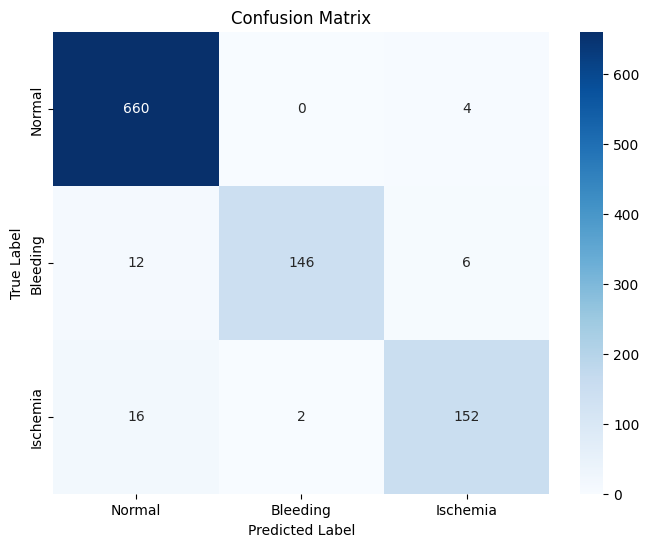


Model saved to models/brain_stroke_model_acc_0.9599.pth

Evaluation finished.


In [13]:
print("\nStarting evaluation on the validation set...")

model.eval()  # Set the model to evaluation mode (disables dropout, uses running stats for batch norm)

all_preds = []
all_labels = []

# Disable gradient calculations for evaluation (saves memory and computation)
with torch.no_grad():
    for inputs, labels in val_loader: # Use the validation loader
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        # Get the predicted class (index with the highest score)
        _, preds = torch.max(outputs, 1)

        # Append batch predictions and labels to the lists
        # Move predictions and labels to CPU before converting to numpy
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Ensure lists are numpy arrays for sklearn functions
all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

# 1. Calculate Accuracy
accuracy = accuracy_score(all_labels, all_preds)
print(f"Validation Accuracy: {accuracy:.4f}")

# 2. Calculate Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

# Get class names from the label map (assuming label_map is accessible)
# If label_map is not accessible, use generic names like ['Class 0', 'Class 1']
try:
    # Need to invert the label_map to get names from indices
    idx_to_label = {v: k for k, v in label_map.items()}
    class_names = [idx_to_label[i] for i in range(NUM_CLASSES)]
except NameError:
    print("Warning: label_map not found. Using generic class names.")
    class_names = [f'Class {i}' for i in range(NUM_CLASSES)]


# 3. Print Classification Report (provides precision, recall, f1-score)
print("\nClassification Report:")
print(classification_report(all_labels, all_preds, target_names=class_names))


# 4. Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')
plt.show()

# 5. Save the best model based on validation accuracy
# Create a directory for saving models if it doesn't exist
os.makedirs('models', exist_ok=True)

# Save the model
model_save_path = f'models/brain_stroke_model_acc_{accuracy:.4f}.pth'
torch.save({
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'val_accuracy': accuracy,
    'train_loss_history': train_loss_history,
}, model_save_path)

print(f"\nModel saved to {model_save_path}")
print("\nEvaluation finished.")



In [9]:
# Define paths for the external test set
test_data_base_path = Path("Brain_Stroke_CT_Dataset/External_Test")
test_csv_path = test_data_base_path / "labels.csv"
test_img_dir = test_data_base_path / "PNG"

print(f"Loading test labels from: {test_csv_path}")
print(f"Looking for test images in: {test_img_dir}")

# Check if paths exist
if not test_csv_path.is_file():
    raise FileNotFoundError(f"Test labels CSV not found at: {test_csv_path}")
if not test_img_dir.is_dir():
    raise FileNotFoundError(f"Test image directory not found at: {test_img_dir}")

# Load the labels CSV
test_labels_df = pd.read_csv(test_csv_path)

# Construct the full image paths
# Assumes image filenames are like '<image_id>.png'
test_labels_df['path'] = test_labels_df['image_id'].apply(
    lambda x: str((test_img_dir / f"{x}.png").resolve())
)

# Rename 'Stroke' column to 'label_encoded' for consistency with our Dataset class
# The CSV already uses 0 for Non-Stroke and 1 for Stroke, matching our likely encoding
test_labels_df = test_labels_df.rename(columns={'Stroke': 'label_encoded'})

# Add the string label column using the existing idx_to_label map
try:
    if 'idx_to_label' not in locals():
         # Recreate idx_to_label if it doesn't exist (e.g., running cells out of order)
         idx_to_label = {v: k for k, v in label_map.items()}
         print("Recreated idx_to_label map.")

    test_labels_df['label'] = test_labels_df['label_encoded'].map(idx_to_label)
except NameError:
    print("Warning: idx_to_label map not found. Cannot create string 'label' column.")
    # Handle cases where label_map/idx_to_label might not be defined
    # If label_map was {'Non_Stroke': 0, 'Stroke': 1}, we can manually map:
    label_mapping_fallback = {0: 'Non_Stroke', 1: 'Stroke'}
    if all(test_labels_df['label_encoded'].isin([0, 1])):
         test_labels_df['label'] = test_labels_df['label_encoded'].map(label_mapping_fallback)
         print("Used fallback mapping for 'label' column.")
    else:
         print("Could not determine string labels for the test set.")


# Select only necessary columns for the dataset
test_df = test_labels_df[['path', 'label', 'label_encoded']].copy()

print(f"\nLoaded {len(test_df)} test samples.")
print("Test DataFrame sample:")
print(test_df.head())

# Verify all image paths exist (optional but recommended)
missing_files = []
for img_path in test_df['path']:
    if not Path(img_path).is_file():
        missing_files.append(img_path)

if missing_files:
    print(f"\nError: {len(missing_files)} image files listed in CSV are missing!")
    # print("Missing files:", missing_files) # Uncomment to see list
    raise FileNotFoundError("Some test image files are missing.")
else:
    print("\nAll test image files verified.")


Loading test labels from: Brain_Stroke_CT_Dataset/External_Test/labels.csv
Looking for test images in: Brain_Stroke_CT_Dataset/External_Test/PNG
Used fallback mapping for 'label' column.

Loaded 200 test samples.
Test DataFrame sample:
                                                path       label  \
0  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Non_Stroke   
1  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Non_Stroke   
2  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Non_Stroke   
3  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Non_Stroke   
4  /home/filip/dev/kaggle/brain_stroke_ct/Brain_S...  Non_Stroke   

   label_encoded  
0              0  
1              0  
2              0  
3              0  
4              0  

All test image files verified.


In [15]:
# --- Create Test Dataset and DataLoader ---

# Ensure the BrainCTDataset class and val_transforms are defined from previous steps
if 'BrainCTDataset' not in locals() or 'val_transforms' not in locals():
     raise NameError("BrainCTDataset class or val_transforms not defined.")
if 'BATCH_SIZE' not in locals() or 'NUM_WORKERS' not in locals():
     raise NameError("BATCH_SIZE or NUM_WORKERS not defined.")


# 1. Instantiate the Test Dataset
#    Use val_transforms for the test set (no data augmentation)
try:
    test_dataset = BrainCTDataset(dataframe=test_df, transform=val_transforms)
    print(f"\nTest dataset created with {len(test_dataset)} samples.")

    # 2. Create the Test DataLoader
    test_loader = DataLoader(
        dataset=test_dataset,
        batch_size=BATCH_SIZE, # Use the same batch size as validation
        shuffle=False,       # DO NOT shuffle the test set
        num_workers=NUM_WORKERS,
        pin_memory=True
    )
    print("Test DataLoader created.")

except Exception as e:
    print(f"Error creating test dataset/dataloader: {e}")
    raise e


Test dataset created with 200 samples.
Test DataLoader created.


In [1]:
print("\nStarting evaluation on the external test set...")
model.load_state_dict(torch.load("best_brain_ct_model.pth"))
model.eval()  # Set the model to evaluation mode

all_test_preds = []
all_test_labels = []

# Disable gradient calculations
with torch.no_grad():
    # Ensure test_loader exists before iterating
    if 'test_loader' not in locals():
        raise NameError("test_loader is not defined. Please run the previous cell to create it.")

    for inputs, labels in test_loader: # Use the test loader defined in the previous cell
        inputs = inputs.to(device)
        labels = labels.to(device)

        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        # Convert 2 to 1 in preds
        preds = torch.where(preds == 2, torch.tensor(1, device=device), preds)
        print(preds)

        all_test_preds.extend(preds.cpu().numpy())
        all_test_labels.extend(labels.cpu().numpy())

# Ensure lists are numpy arrays
all_test_preds = np.array(all_test_preds)
all_test_labels = np.array(all_test_labels)

# 1. Calculate Accuracy
test_accuracy = accuracy_score(all_test_labels, all_test_preds)
print(f"Test Set Accuracy: {test_accuracy:.4f}")

# 2. Calculate Confusion Matrix
test_cm = confusion_matrix(all_test_labels, all_test_preds)

# 3. Print Classification Report
# Use the same class_names as before (should be defined from validation step or test data prep)
if 'class_names' not in locals():
     print("Warning: class_names not found. Using generic names for report/plot.")
     # Attempt to get number of classes from confusion matrix shape
     num_test_classes = test_cm.shape[0]
     class_names = [f'Class {i}' for i in range(num_test_classes)]


print("\nTest Set Classification Report:")
print(classification_report(all_test_labels, all_test_preds, target_names=class_names))

# 4. Visualize Confusion Matrix
plt.figure(figsize=(8, 6))
# Only show the actual values in the confusion matrix (TP, FP, FN, TN)
sns.heatmap(test_cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Test Set Confusion Matrix')
plt.show()

print("\nTest set evaluation finished.")


Starting evaluation on the external test set...


NameError: name 'model' is not defined